<a href="https://colab.research.google.com/github/BillianTrg/OOP/blob/main/SM_MLR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("Life Expectancy Data.csv")

# Xem dữ liệu
print(df.head())
print(df.info())
print(df.describe())

       Country  Year      Status  Life expectancy   Adult Mortality  \
0  Afghanistan  2015  Developing              65.0            263.0   
1  Afghanistan  2014  Developing              59.9            271.0   
2  Afghanistan  2013  Developing              59.9            268.0   
3  Afghanistan  2012  Developing              59.5            272.0   
4  Afghanistan  2011  Developing              59.2            275.0   

   infant deaths  Alcohol  percentage expenditure  Hepatitis B  Measles   ...  \
0             62     0.01               71.279624         65.0      1154  ...   
1             64     0.01               73.523582         62.0       492  ...   
2             66     0.01               73.219243         64.0       430  ...   
3             69     0.01               78.184215         67.0      2787  ...   
4             71     0.01                7.097109         68.0      3013  ...   

   Polio  Total expenditure  Diphtheria    HIV/AIDS         GDP  Population  \
0    6.

In [8]:
# Rename cột cho dễ dùng (tránh space)
df.columns = df.columns.str.strip().str.replace(" ", "_")

# Drop missing (cách nhanh nhất cho bài)
df = df.dropna()

In [9]:
# Target (Y)
y = df["Life_expectancy"]

# Independent variables (X)
X = df[[
    "Adult_Mortality",
    "GDP",
    "Schooling",
    "HIV/AIDS",
    "Alcohol"
]]

In [6]:
# Status: Developing / Developed
df["Status_dummy"] = df["Status"].map({
    "Developing": 0,
    "Developed": 1
})

# Add vào X
X["Status_dummy"] = df["Status_dummy"]

/tmp/ipykernel_16862/116313323.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X["Status_dummy"] = df["Status_dummy"]


In [12]:
from statsmodels.stats.diagnostic import het_breuschpagan
import statsmodels.api as sm

# Add a constant to the independent variables for the OLS model
X_const = sm.add_constant(X)

# Fit the OLS model
model = sm.OLS(y, X_const).fit()

# Calculate residuals from the fitted model
residuals = model.resid

bp_test = het_breuschpagan(residuals, X_const)
print("Breusch-Pagan p-value:", bp_test[1])

Breusch-Pagan p-value: 2.798547198334141e-35


                 Life_expectancy  Adult_Mortality       GDP  Schooling  \
Life_expectancy         1.000000        -0.702523  0.441322   0.727630   
Adult_Mortality        -0.702523         1.000000 -0.255035  -0.421171   
GDP                     0.441322        -0.255035  1.000000   0.467947   
Schooling               0.727630        -0.421171  0.467947   1.000000   
HIV/AIDS               -0.592236         0.550691 -0.108081  -0.211840   
Alcohol                 0.402718        -0.175535  0.443433   0.616975   
Status_dummy            0.442798        -0.278173  0.484801   0.512543   

                 HIV/AIDS   Alcohol  Status_dummy  
Life_expectancy -0.592236  0.402718      0.442798  
Adult_Mortality  0.550691 -0.175535     -0.278173  
GDP             -0.108081  0.443433      0.484801  
Schooling       -0.211840  0.616975      0.512543  
HIV/AIDS         1.000000 -0.027113     -0.129555  
Alcohol         -0.027113  1.000000      0.607782  
Status_dummy    -0.129555  0.607782      1.

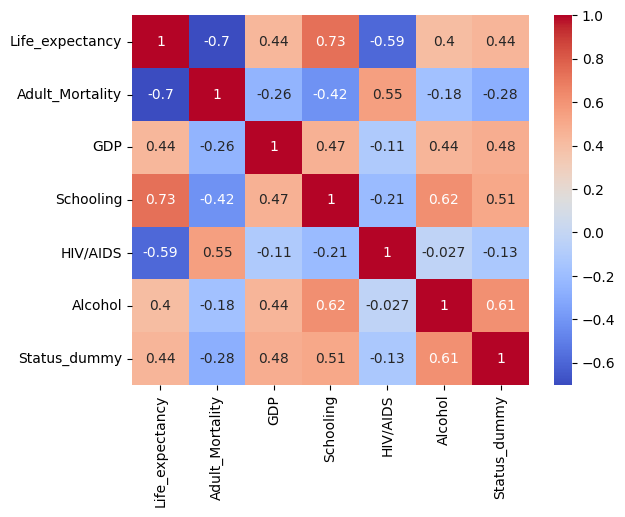

In [13]:
corr_matrix = df[[
    "Life_expectancy",
    "Adult_Mortality",
    "GDP",
    "Schooling",
    "HIV/AIDS",
    "Alcohol",
    "Status_dummy"
]].corr()

print(corr_matrix)

sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.show()

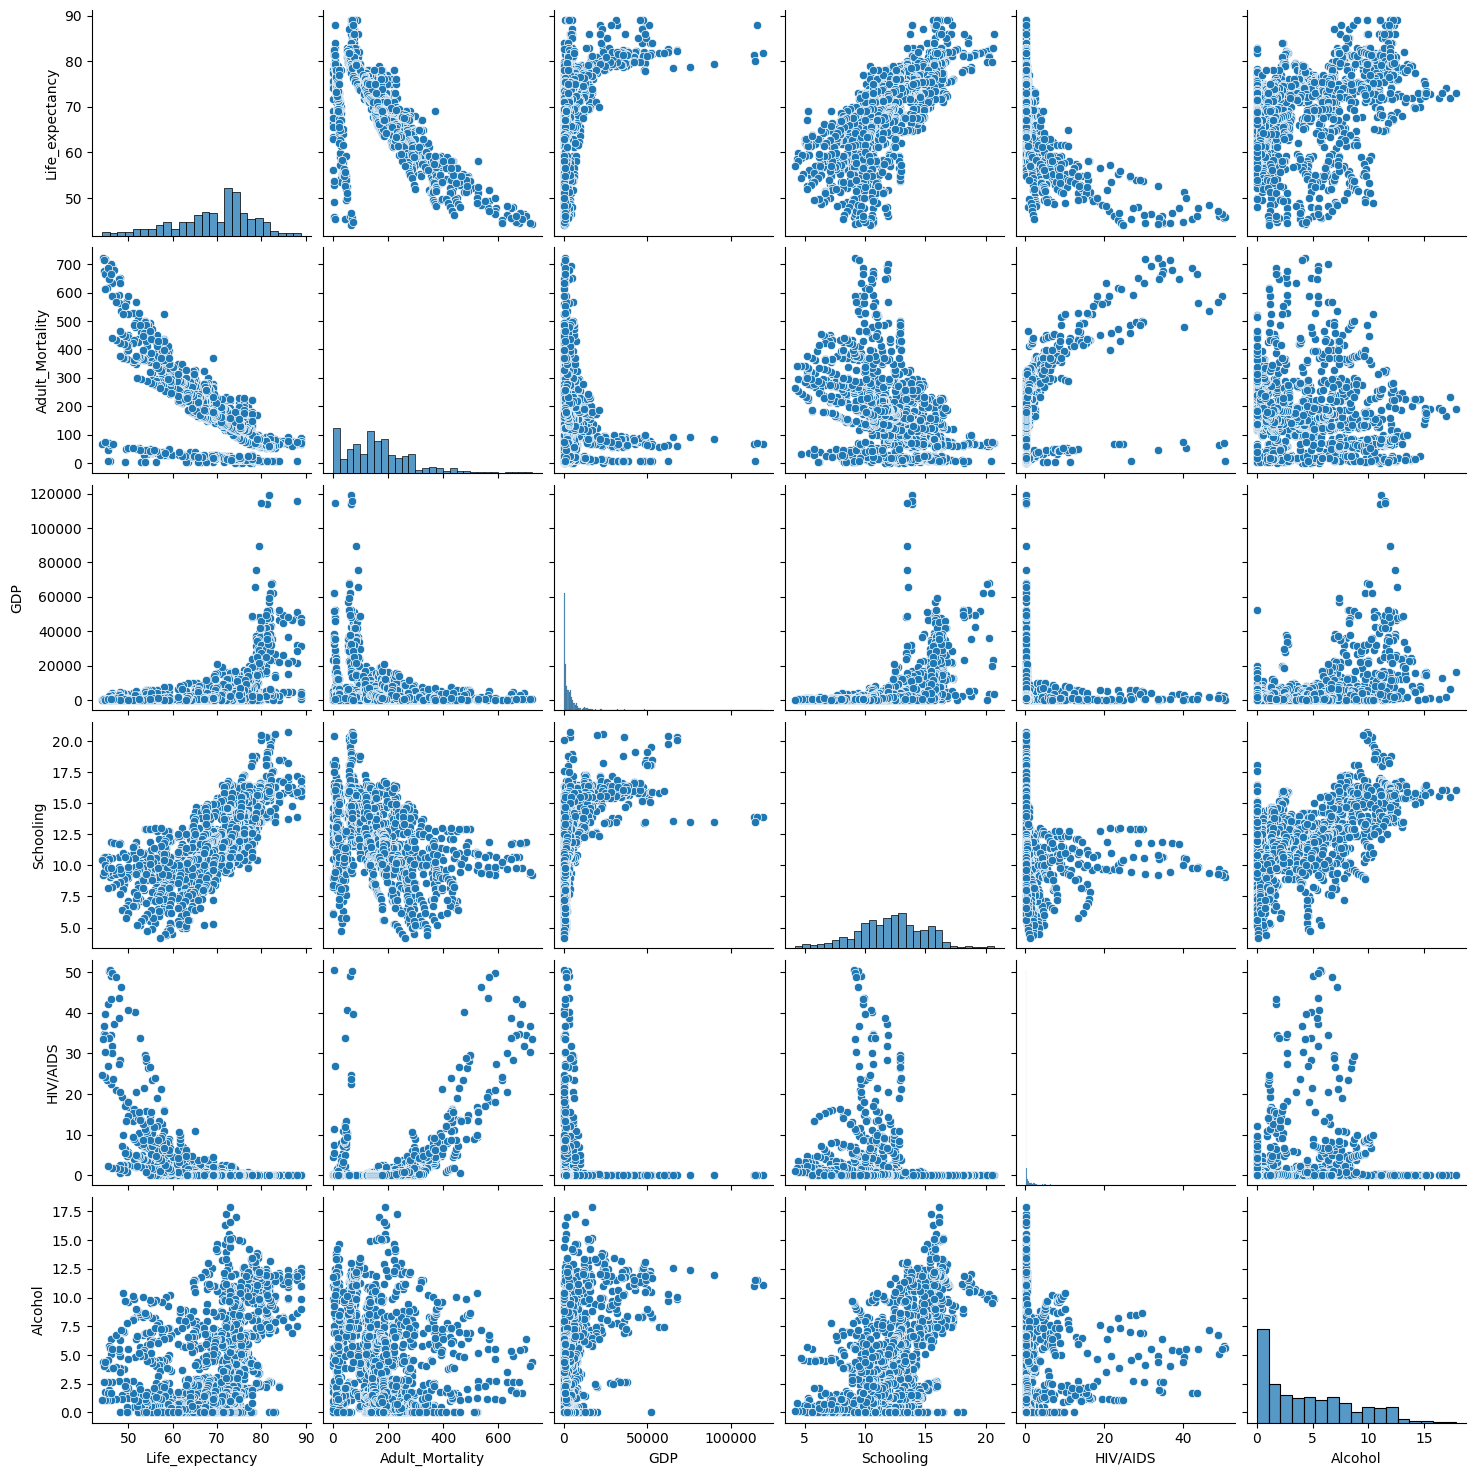

In [14]:
sns.pairplot(df[[
    "Life_expectancy",
    "Adult_Mortality",
    "GDP",
    "Schooling",
    "HIV/AIDS",
    "Alcohol"
]])
plt.show()

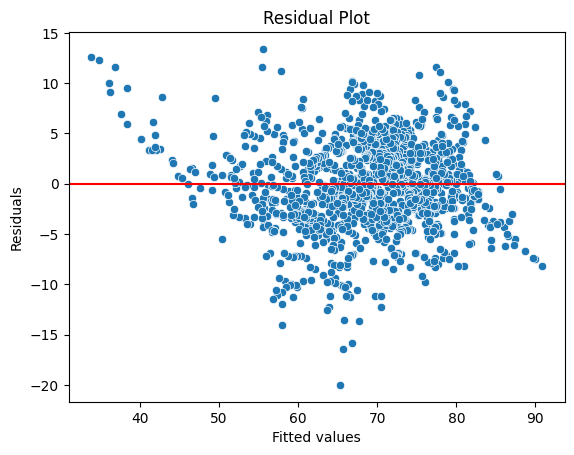

In [15]:
residuals = model.resid
fitted = model.fittedvalues

sns.scatterplot(x=fitted, y=residuals)
plt.axhline(0, color='red')
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

In [23]:
#Run MLR
import statsmodels.api as sm

# Use the independent variables prepared in previous cells
X = df[["Adult_Mortality", "GDP", "Schooling", "HIV/AIDS", "Alcohol", "Status_dummy"]]
X = sm.add_constant(X)
# Use the dependent variable prepared in previous cells
y = df["Life_expectancy"]

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:        Life_expectancy   R-squared:                       0.796
Model:                            OLS   Adj. R-squared:                  0.796
Method:                 Least Squares   F-statistic:                     1070.
Date:                Wed, 29 Apr 2026   Prob (F-statistic):               0.00
Time:                        05:46:15   Log-Likelihood:                -4613.2
No. Observations:                1649   AIC:                             9240.
Df Residuals:                    1642   BIC:                             9278.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              54.7619      0.614     

In [19]:
from scipy import stats

t_stat, p_value = stats.ttest_1samp(residuals, 0)
print("t-stat:", t_stat)
print("p-value:", p_value)

t-stat: 1.0232629730933028e-12
p-value: 0.9999999999991837


In [26]:
from statsmodels.stats.diagnostic import het_breuschpagan

bp_test = het_breuschpagan(residuals, model.model.exog)
print("Breusch-Pagan p-value: ", bp_test[1])

Breusch-Pagan p-value:  1.0158426171043946e-34


In [21]:
import scipy.stats as stats

# Shapiro-Wilk
print("Shapiro p-value:", stats.shapiro(residuals).pvalue)

# Normal test
print("Normaltest p-value:", stats.normaltest(residuals)[1])

# Jarque-Bera
jb = stats.jarque_bera(residuals)
print("JB statistic:", jb[0])
print("p-value:", jb[1])


Shapiro p-value: 1.7182732912043e-11
Normaltest p-value: 1.6184337683077748e-17
JB statistic: 133.8435002545427
p-value: 8.634818243378071e-30


In [22]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif = pd.DataFrame()
vif["Variable"] = X.columns
vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print(vif)

          Variable       VIF
0  Adult_Mortality  3.376054
1              GDP  1.641893
2        Schooling  5.351329
3         HIV/AIDS  1.596684
4          Alcohol  3.516752
